# Predictive modeling

## EDA

### Trajectory clustering experiments

#### CLuster comparisons

very draft level - 21Sept26 - not even baseline BC incorporated! and data is not pulled from a TTE table, but from all across the database. And, again, these clusters are NOT very refined, and well-defined, clusters yet!

NEW

In [2]:
# -------------------------------------------------------------------------
# Cluster Comparisons & Statistical Pipeline (V2)
# -------------------------------------------------------------------------
import os
import sys

# Import our refactored comparison module
from cluster_comparisons import build_comparison_table

# -------------------------------------------------------------------------
# 1. CONFIGURATION
# -------------------------------------------------------------------------
SOURCE_DB_PATH = "../dbs/pnk_db2_filtered.sqlite"
# Pointing to the specific directory where your most trustworthy MVP3 run lives
OUT_DB_PATH = "../out/mdtw_mvp3_abs_bc_patientid_level/out_db.sqlite"

# Set the unit of analysis: 'medical_record_id' or 'patient_id'
ID_COL = "patient_id"

CLUSTER_TABLE = "dtw_mvp3_cluster_labels"
TARGET_TABLE = "cluster_comparison_table"

# Map the internal cluster IDs to display names. 
# -1 is automatically generated internally for records with only 1 weigh-in.
# Manually name clusters, and EXCLUDE any n=1 cluster(s), as these are outliers. Base this on inspecting the LOWESS trajectory plots. 
COHORT_NAMES = {
    -1: "cl0_immediate_attrition",
    0:  "cl1_large_loss",
    1:  "cl2_early_attrition",
    2:  "c3_moderate_loss",
    3:  "cl4_regain"
}

# -------------------------------------------------------------------------
# 2. EXECUTION
# -------------------------------------------------------------------------
build_comparison_table(
    source_db_path=SOURCE_DB_PATH,
    out_db_path=OUT_DB_PATH,
    cluster_table=CLUSTER_TABLE,
    target_table_name=TARGET_TABLE,
    cohort_names=COHORT_NAMES,
    id_col=ID_COL
)

# -------------------------------------------------------------------------
# 3. VERIFICATION
# -------------------------------------------------------------------------
import sqlite3
import pandas as pd

conn = sqlite3.connect(OUT_DB_PATH)
df_results = pd.read_sql_query(f"SELECT * FROM {TARGET_TABLE}", conn)
conn.close()

# Display the top rows of the results table
display(df_results.head(30))


Starting Cluster Comparisons Pipeline (Level: patient_id)...
Fetching and processing longitudinal measurements at the patient_id level...
Fetching cross-sectional medical records at the patient_id level...
Aggregating time-varying covariates to the patient level...
Fetching and processing genomics data...
Merging data...
Data constructed. Total records for comparison: 13522
Running statistical comparisons...
Saving comparison table to ../out/mdtw_mvp3_abs_bc_patientid_level/out_db.sqlite -> table 'cluster_comparison_table'...
Done! Cluster comparison complete.


,Variable,cl0_immediate_attrition,cl1_large_loss,cl2_early_attrition,c3_moderate_loss,cl4_regain,p_value_fdr
0,Cluster Size (N),441,1384,8008,2983,706,NA
1,age_when_creating_record,46.91 ± 11.68 (n=441),47.44 ± 10.27 (n=1384),46.88 ± 10.84 (n=8008),45.81 ± 10.15 (n=2983),45.81 ± 10.19 (n=706),0.0000
2,sex_f,347 (78.7%),840 (60.7%),6600 (82.4%),2414 (80.9%),573 (81.2%),0.0000
3,height_m,1.65 ± 0.08 (n=441),1.70 ± 0.09 (n=1384),1.65 ± 0.08 (n=8008),1.65 ± 0.08 (n=2983),1.66 ± 0.08 (n=706),0.0000
4,wc_cm_confirm_time,99.75 ± 14.79 (n=144),109.46 ± 15.89 (n=586),100.86 ± 15.81 (n=2811),98.55 ± 14.58 (n=1127),98.59 ± 14.25 (n=346),0.0000
5,nr_medical_records_patient,1.31 ± 0.75 (n=441),1.41 ± 0.73 (n=1384),1.36 ± 0.75 (n=8008),1.47 ± 0.79 (n=2983),2.34 ± 1.09 (n=706),0.0000
6,dietitian_visits,2.57 ± 4.36 (n=441),6.98 ± 5.04 (n=1382),3.72 ± 3.64 (n=8002),5.76 ± 4.27 (n=2983),6.24 ± 7.19 (n=706),0.0000
7,womens_health_and_pregnancy,23 (33.8%),42 (19.4%),395 (29.5%),131 (24.8%),28 (24.6%),0.0282
8,mental_health,16 (23.5%),50 (23.1%),322 (24.0%),137 (25.9%),26 (22.8%),0.9558
9,family_issues,4 (5.9%),14 (6.5%),75 (5.6%),20 (3.8%),4 (3.5%),0.6819


OLD

In [11]:
# -------------------------------------------------------------------------
# Cluster Comparisons & Statistical Pipeline
# -------------------------------------------------------------------------
import os
import sys

# Import our new comparison module
from cluster_comparisons import build_comparison_table

# -------------------------------------------------------------------------
# 1. CONFIGURATION
# -------------------------------------------------------------------------
SOURCE_DB_PATH = "../dbs/pnk_db2_filtered.sqlite"
# Pointing to the specific directory where your most trustworthy MVP3 run lives
OUT_DB_PATH = "../out/mdtw_mvp3_abs_bc_recordid_level/out_db.sqlite"

CLUSTER_TABLE = "dtw_mvp3_cluster_labels"
TARGET_TABLE = "cluster_comparison_table"

# Map the internal cluster IDs to display names. 
# -1 is automatically generated internally for records with only 1 weigh-in.
# Cluster 2 is deliberately omitted to exclude the n=1 outlier cluster.
COHORT_NAMES = {
    -1: "cl0_lost_to_followup",
    0:  "cl1_fast_losers",
    1:  "cl2_regainers",
    3:  "cl3_slow_losers"
}

# -------------------------------------------------------------------------
# 2. EXECUTION
# -------------------------------------------------------------------------
# This will extract data across 3 tables, engineer features, assign cohorts,
# run Kruskal-Wallis/Chi-Square tests, apply FDR correction, and save the table.
build_comparison_table(
    source_db_path=SOURCE_DB_PATH,
    out_db_path=OUT_DB_PATH,
    cluster_table=CLUSTER_TABLE,
    target_table_name=TARGET_TABLE,
    cohort_names=COHORT_NAMES
)

# You can then query the resulting table using pandas to view it in the notebook:
import sqlite3
import pandas as pd

conn = sqlite3.connect(OUT_DB_PATH)
df_results = pd.read_sql_query(f"SELECT * FROM {TARGET_TABLE}", conn)
conn.close()

# Display the top rows of the results table
display(df_results.head(20))


Starting Cluster Comparisons Pipeline...
Fetching and processing longitudinal measurements...
Fetching and processing cross-sectional medical records...
Fetching and processing genomics data...
Merging data...
Data constructed. Total records for comparison: 16704
Running statistical comparisons...
Saving comparison table to ../out/mdtw_mvp3_abs_bc_recordid_level/out_db.sqlite -> table 'cluster_comparison_table'...
Done! Cluster comparison complete.


,Variable,cl0_lost_to_followup,cl1_fast_losers,cl2_regainers,cl3_slow_losers,p_value_fdr
0,age_when_creating_record,47.63 ± 11.14 (n=814),46.74 ± 10.46 (n=2236),47.31 ± 10.70 (n=8438),46.68 ± 10.32 (n=5216),0.0268
1,sex_f,658 (80.8%),1494 (66.8%),7011 (83.1%),4130 (79.2%),0.0000
2,height_m,1.65 ± 0.08 (n=814),1.68 ± 0.09 (n=2236),1.65 ± 0.08 (n=8438),1.66 ± 0.08 (n=5216),0.0000
3,wc_cm_confirm_time,100.06 ± 14.56 (n=216),105.55 ± 15.91 (n=892),99.81 ± 15.63 (n=2489),99.80 ± 14.67 (n=1777),0.0000
4,nr_medical_records_patient,2.05 ± 1.19 (n=814),1.56 ± 0.84 (n=2236),1.83 ± 1.10 (n=8438),1.58 ± 0.88 (n=5216),0.0000
5,dietitian_visits,2.12 ± 3.41 (n=813),6.84 ± 4.88 (n=2234),3.22 ± 3.72 (n=8429),4.95 ± 3.81 (n=5216),0.0000
6,womens_health_and_pregnancy,26 (29.5%),69 (20.6%),307 (27.6%),226 (28.5%),0.1381
7,mental_health,21 (23.9%),86 (25.7%),260 (23.4%),204 (25.7%),0.8365
8,family_issues,6 (6.8%),19 (5.7%),56 (5.0%),44 (5.5%),0.9468
9,medication_disease_injury,18 (20.5%),47 (14.0%),198 (17.8%),123 (15.5%),0.4808


#### MVP3, 21Sept26 - Configurable whole patient trajectory vs medical record level clustering, with BC values converted to absolutes

##### details

GOAL
- to identify weight loss and ABSOLUTE body composition change trajectory clusters

DATAPREP
- configurable choice within whole patient trajectories and unique treatment episodes (unit of analysis determined by patient_id or medical_record_id respectively)
- configurable choice of input variables - ideally, weight, muscle, and fat, to balance detail with dimensionality
- instant dropouts with only 1 weigh-in excluded - dtw needs serial data - but clinically, they constitute the 0th cluster that should be characterized
- patients with missing BC excluded - dtw needs complete data - missing data would need imputation if we want to use all
- patients with outlier weight and BC values excluded - extreme outliers can form their own n=1 cluster
- BC % values converted to absolutes based on weight_kg - relative muscle mass 'growth' can confuse the DTW clustering algorithm
- most adherent patients excluded: patients more than a given number (ideally the 95th percentile, or a lower number like 50) weigh-ins excluded from this MVP run, because it slows down early iteration - but these patients are valuable, the top 10% of patients have an average of 107 weigh-ins, and the top has 752
- tensor formatting: uneven patient histories are zero-padded with NaNs and pivoted into a 3D tensor (this is standard for DTW as far as I understand)

ML ARCHITECTURE
- algorithm: TimeSeriesKMeans with dynamic time warping. DTW aligns sequence shapes elastically, neutralizing irregular gaps between weigh-ins. It natively ignores NaN padding. K-means might not be the best algorithm choice though, so in further iterations, PAM, k-series, hclust, or mLCGA with FDA-based approaches should be explored
- k selection: by default, k 2-7 evaluated, best k selected with the elbow method (inertia) to keep computational costs low. In more serious builds, a comprehensive evaluation with inertia, silhouette, CHI, DBI, maybe even ARI should be considered. 

VISUALIZATION
- model-derived: DTW barycenters / raw mathematical cluster centers plotted around warped time steps to emphasize the model-derived SHAPE of the weight loss response
- raw, LOWESS-smoothed: per cluster, raw change trajectories are plotted, to see if clusters actually look coherent in real life, or only their warped trajectory shape

##### code

Loading data from ../dbs/pnk_db2_filtered.sqlite...
Initial data: 396210 rows, 14515 unique patient_ids.
After dropping missing values in targets: 360306 rows.
After dropping biological raw outliers: 360301 rows.
After enforcing >=2 timepoints: 359633 rows, 13770 unique patient_ids remaining.
95th percentile of weigh-ins per patient_id: 82.0
Max weigh-ins per patient_id: 749
After capping at 82 timepoints: 262353 rows, 13082 unique patient_ids.
Converting percentage variables to absolute kilograms...
Updated target columns for clustering: ['weight_kg', 'fat_kg', 'muscle_kg']
Calculating days from baseline for time axis using patient_id...
Calculating percentage change from baseline...
Reshaping data for tslearn...
Dataset reshaped successfully. Shape: (13082, 82, 3)
Starting DTW KMeans search for k in range 2-7...

--- Fitting k=2 ---
k=2 | Inertia: 1468.36

--- Fitting k=3 ---
k=3 | Inertia: 1341.11

--- Fitting k=4 ---
k=4 | Inertia: 1091.88

--- Fitting k=5 ---
k=5 | Inertia: 854.32

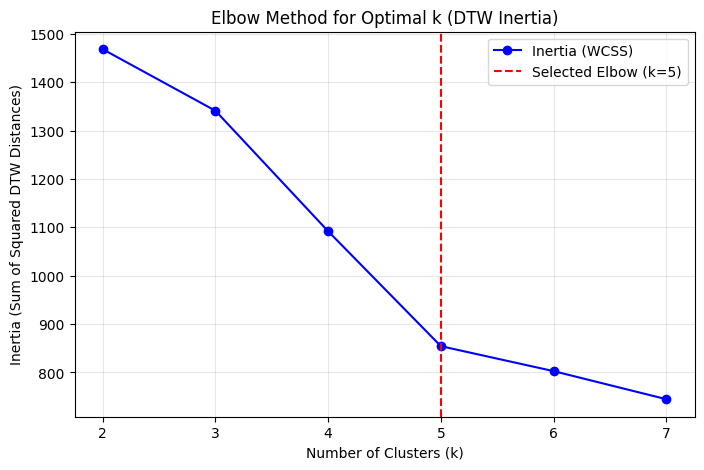

Saving cluster assignments to ../out/mdtw_mvp3_abs_bc_patientid_level/out_db.sqlite -> table 'dtw_mvp3_cluster_labels'...
Database save complete.

Plotting DTW Barycenters...
Saved DTW Barycenters plot to ../out/mdtw_mvp3_abs_bc_patientid_level/dtw_mvp3_barycenters.png


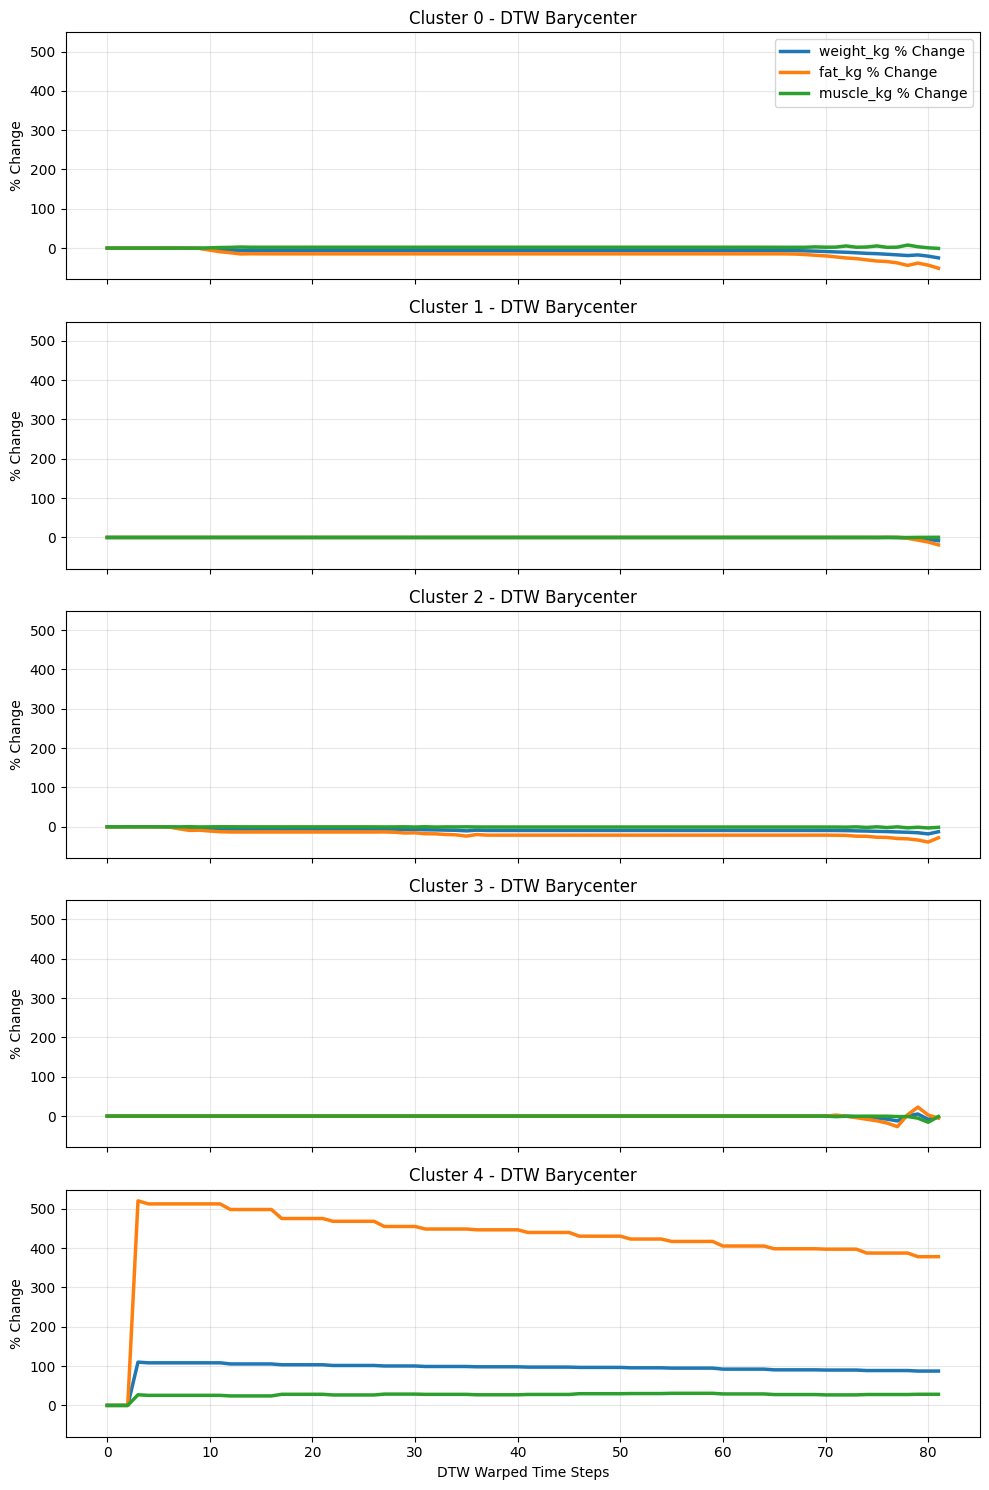


Plotting real-time LOWESS trajectories...
Saved LOWESS plot to ../out/mdtw_mvp3_abs_bc_patientid_level/dtw_mvp3_lowess.png


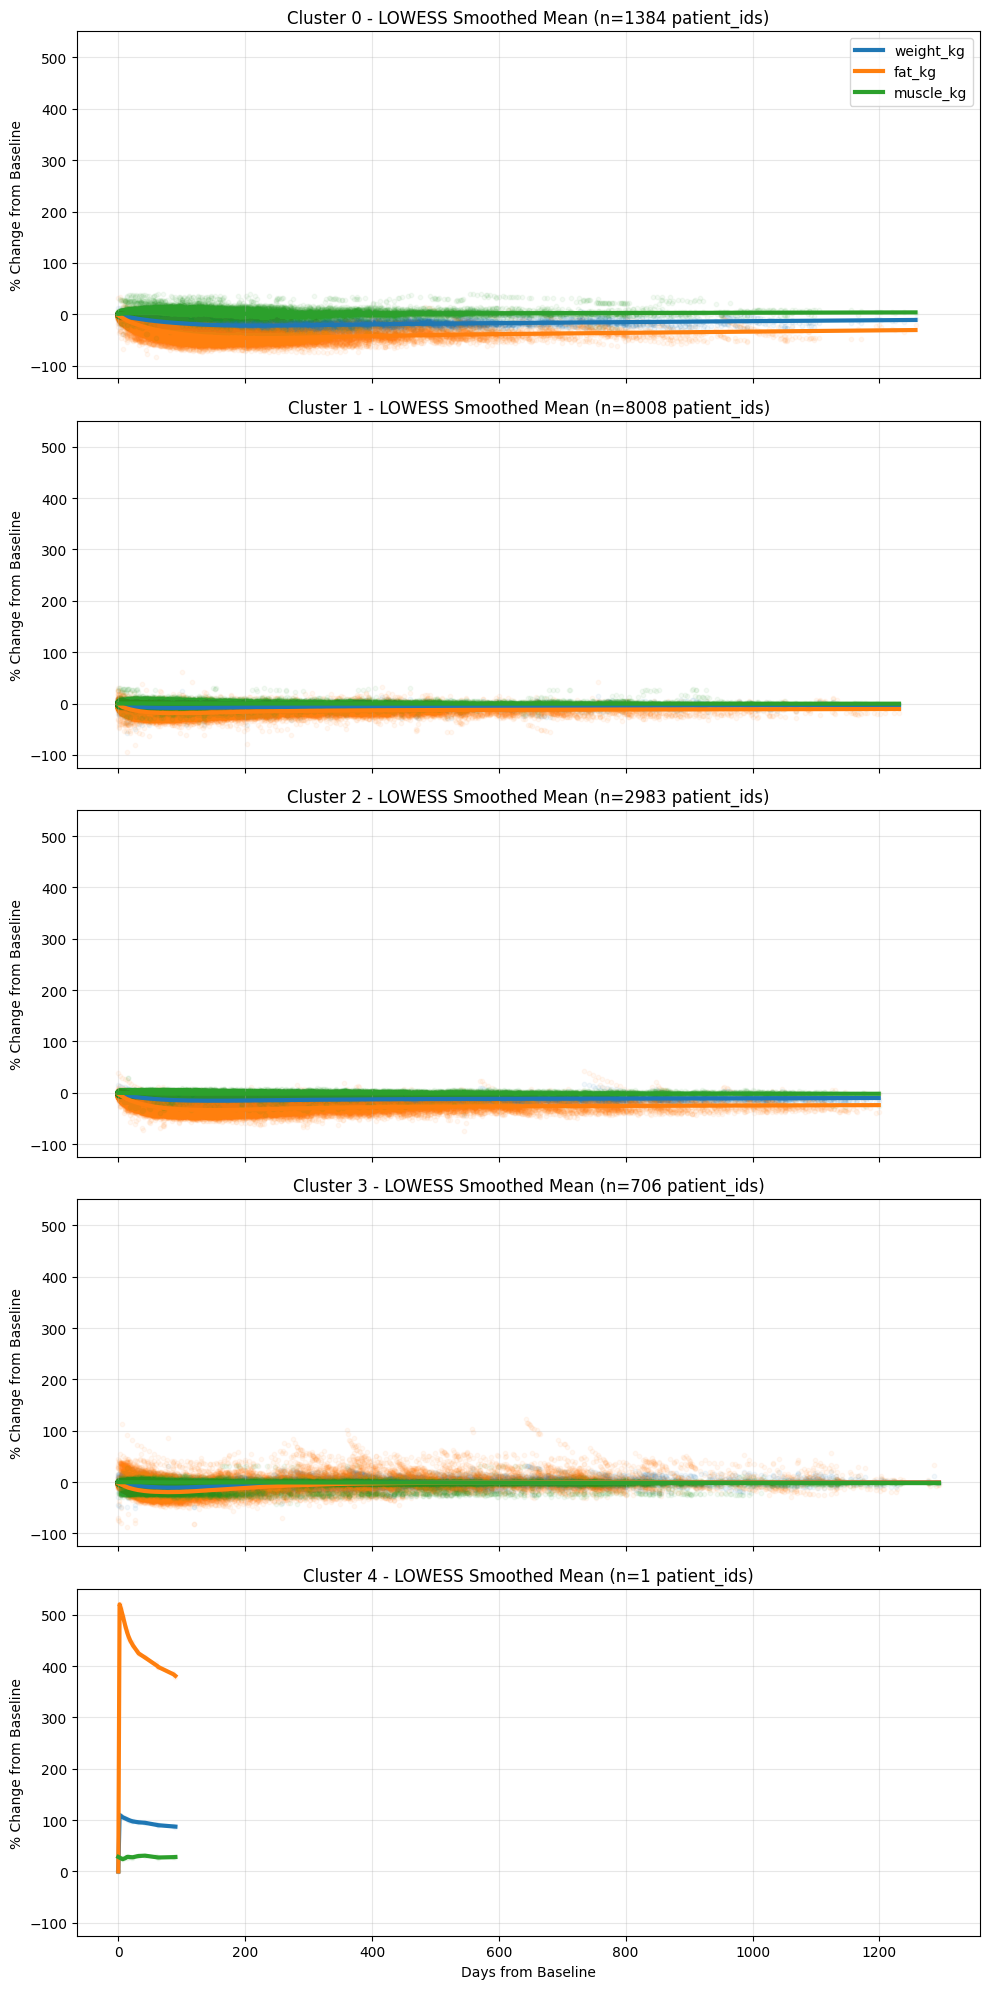

In [3]:
# -------------------------------------------------------------------------
# Dynamic Time Warping with K-means on longitudinal trajectories - MVP3
# -------------------------------------------------------------------------
import os
import sys

# Import our modular pipeline functions
from mdtw_mvp3 import (
    load_and_filter_measurements,
    convert_percentages_to_absolute,
    calculate_days_from_baseline,
    calculate_percentage_from_baseline,
    prepare_tslearn_dataset,
    run_dtw_clustering_search,
    save_clusters_to_db,
    plot_dtw_barycenters,
    plot_lowess_trajectories
)

# -------------------------------------------------------------------------
# 1. CONFIGURATION
# -------------------------------------------------------------------------
DB_PATH = "../dbs/pnk_db2_filtered.sqlite"
OUT_DB_PATH = "../out/mdtw_mvp3_abs_bc_patientid_level/out_db.sqlite"
OUT_TABLE = "dtw_mvp3_cluster_labels"

ID_COL = "patient_id"
# We define the raw columns from the database. The script will automatically 
# convert any % variables into their absolute _kg equivalents.
TARGET_COLS = ["weight_kg", "fat_%", "muscle_%"]
MAX_WEIGHINS = 82

# -------------------------------------------------------------------------
# 2. DATA PREPARATION (Now with absolute body comp conversion)
# -------------------------------------------------------------------------
df_raw = load_and_filter_measurements(
    db_path=DB_PATH, 
    id_col=ID_COL, 
    target_cols=TARGET_COLS, 
    max_weighins=MAX_WEIGHINS
)

# NEW: Convert percentages to absolute values (kg) to prevent artifactual 
# muscle/fat growth signals caused solely by a drop in total body weight.
# Returns updated_targets which will now be ['weight_kg', 'fat_kg', 'muscle_kg']
df_abs, updated_targets = convert_percentages_to_absolute(
    df_raw, 
    target_cols=TARGET_COLS
)

df_time = calculate_days_from_baseline(df_abs, id_col=ID_COL)

# Percentage change from baseline is now calculated on the absolute kg values
df_pct = calculate_percentage_from_baseline(
    df_time, 
    id_col=ID_COL, 
    target_cols=updated_targets
)

ts_dataset, entity_ids = prepare_tslearn_dataset(
    df_pct, 
    id_col=ID_COL, 
    target_cols=updated_targets
)

# -------------------------------------------------------------------------
# 3. MODELING & CLUSTERING 
# -------------------------------------------------------------------------
best_k, best_model, best_labels = run_dtw_clustering_search(
    ts_dataset=ts_dataset, 
    k_min=2, 
    k_max=7, 
    elbow_plot_path="../out/mdtw_mvp3_abs_bc_patientid_level/dtw_mvp3_elbow_curve.png"
)

save_clusters_to_db(
    ids=entity_ids, 
    labels=best_labels, 
    db_path=OUT_DB_PATH, 
    table_name=OUT_TABLE,
    id_col=ID_COL
)

# -------------------------------------------------------------------------
# 4. VISUALIZATION
# -------------------------------------------------------------------------
print("\nPlotting DTW Barycenters...")
plot_dtw_barycenters(
    model=best_model, 
    target_cols=updated_targets, 
    output_path="../out/mdtw_mvp3_abs_bc_patientid_level/dtw_mvp3_barycenters.png"
)

print("\nPlotting real-time LOWESS trajectories...")
plot_lowess_trajectories(
    df=df_pct, 
    ids=entity_ids, 
    labels=best_labels, 
    id_col=ID_COL,
    target_cols=updated_targets,
    output_path="../out/mdtw_mvp3_abs_bc_patientid_level/dtw_mvp3_lowess.png"
)


Annex - runs from memory - clean LOWESS plots. With medical_record_id as the unit, there is a n=1 cluster of a patient whose first weight is a low outlier. Thus, their WL pattern has a huge upwards spike which differs from all the rest. To represent the rest of the more realistic clusters on a cleaned LOWESS plot, this patient is masked from plotting. This can only be done if the clustering pipeline has ran recently and remains in memory. 

Saved LOWESS plot to ../out/dtw_mvp3_cleaned_lowess.png


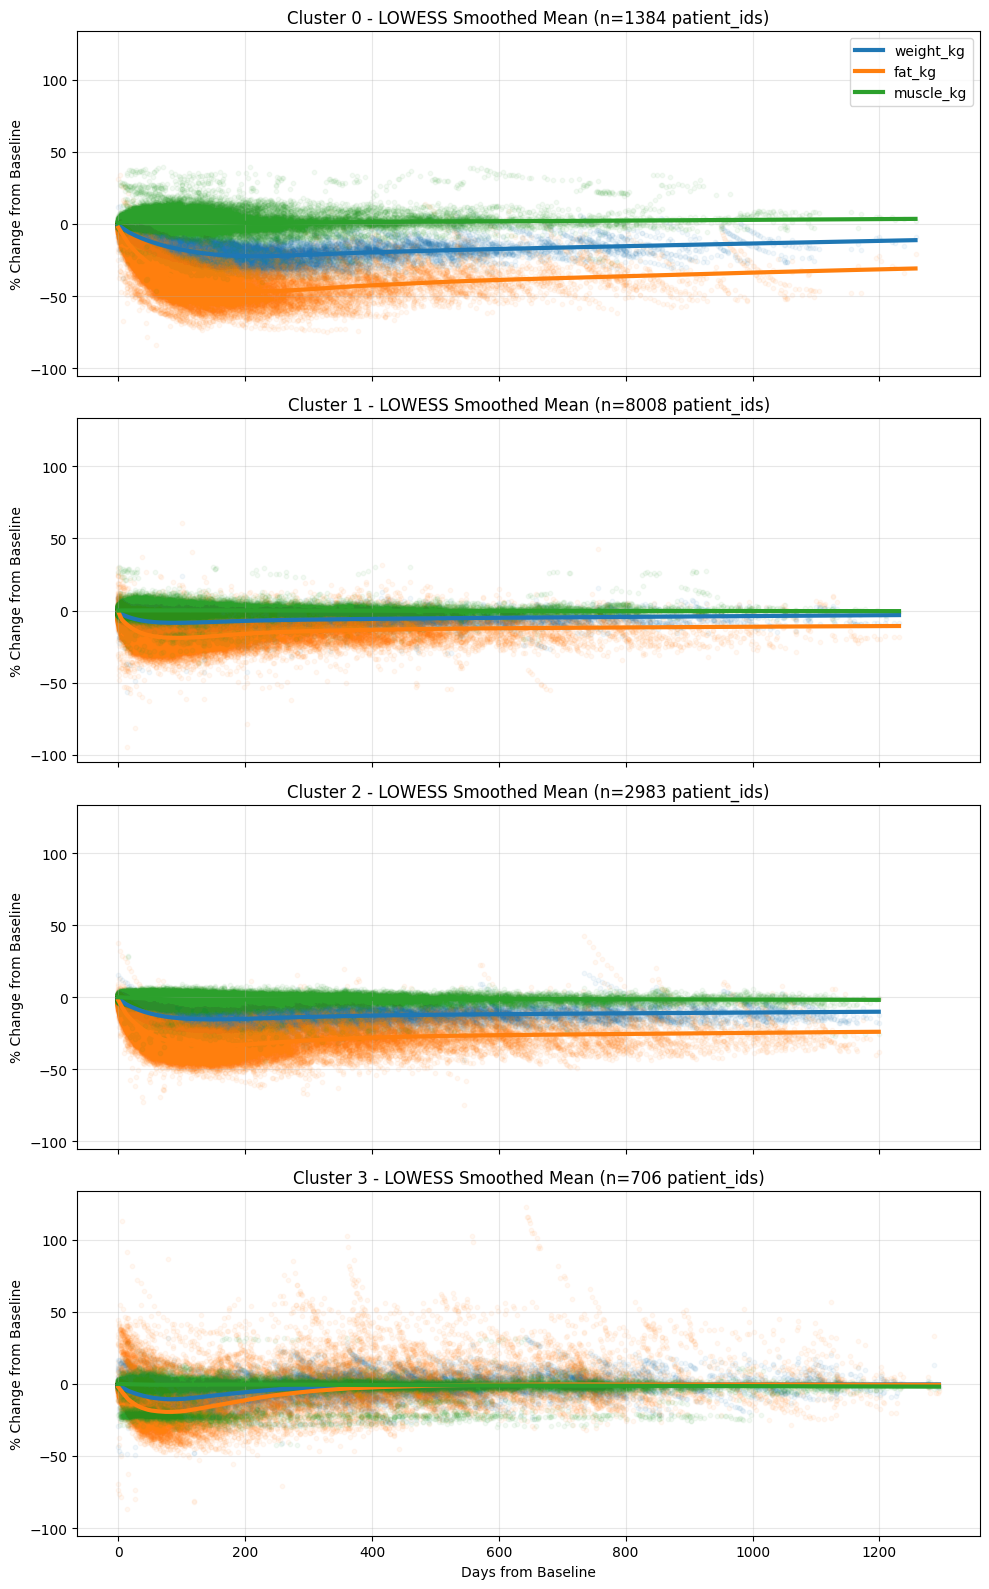

In [7]:
import numpy as np

# 1. Identify valid mask and IDs (excluding Cluster 2)
valid_mask = (best_labels != 4)
valid_ids = np.array(entity_ids)[valid_mask]
valid_labels = best_labels[valid_mask].copy()

# 2. THE FIX: Shift label '3' down to '2' to make them consecutive (0, 1, 2)
valid_labels[valid_labels == 4] = 3

# 3. Filter the long-format dataframe to only include valid entities
valid_clusters_df = df_pct[df_pct[ID_COL].isin(valid_ids)].copy()

# 4. Re-plot the LOWESS curves
plot_lowess_trajectories(
    df=valid_clusters_df, 
    ids=valid_ids.tolist(), 
    labels=valid_labels, 
    id_col=ID_COL,
    target_cols=updated_targets,
    output_path="../out/dtw_mvp3_cleaned_lowess.png"
)

Annex - runs from memory - similar to the LOWESS plots, the barycenter plots are also recreated cleanly, from memory. 

Saved DTW Barycenters plot to ../out/dtw_mvp3_cleaned_barycenters.png


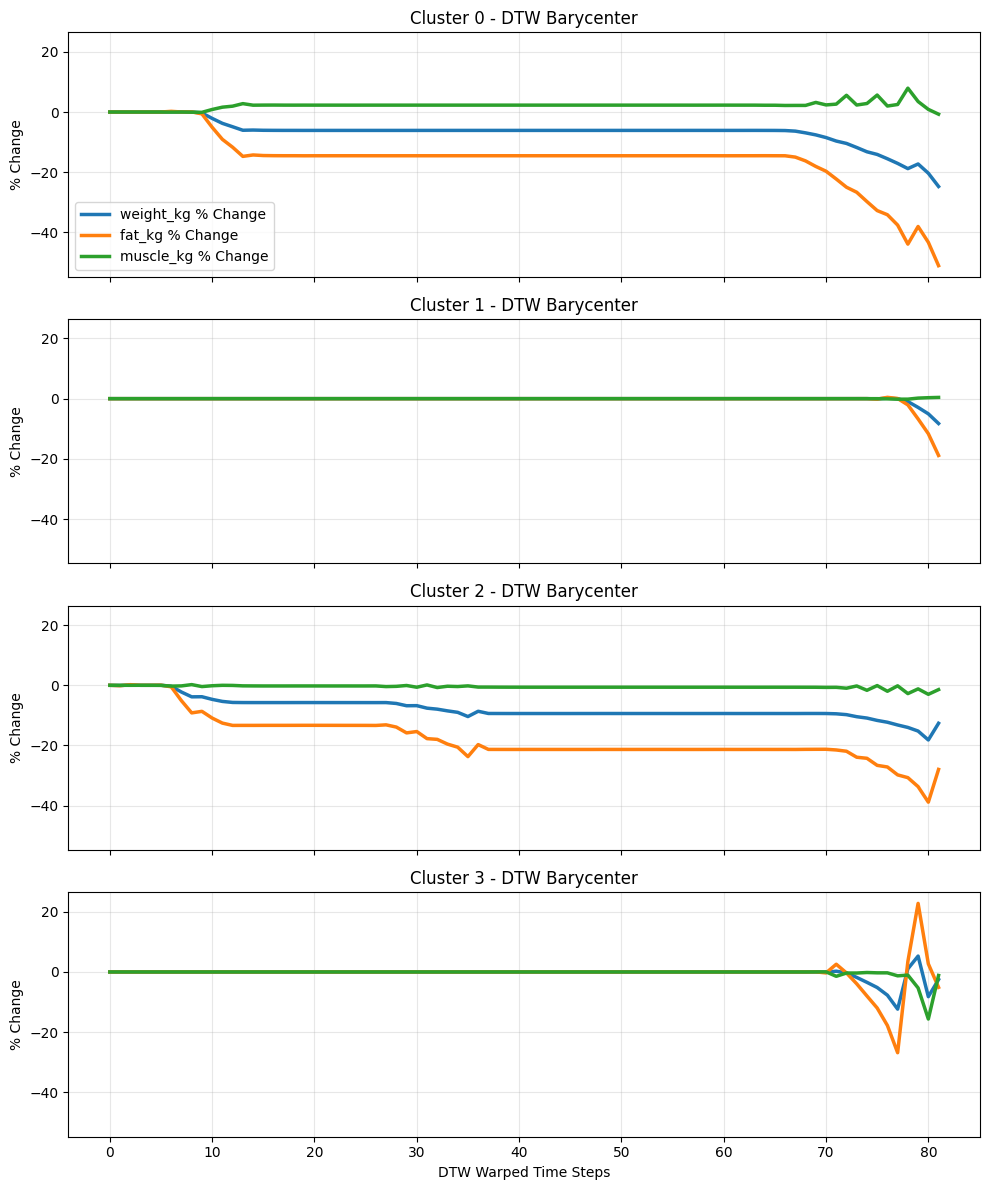

In [10]:
import copy
import numpy as np

# 1. Create a copy of the model so we don't alter the original saved object
cleaned_model = copy.deepcopy(best_model)

# 2. Delete the quarantine cluster's barycenter (index 2) from the centers array
# The shape is (k, max_timepoints, n_targets). axis=0 deletes the 3rd cluster matrix.
cleaned_model.cluster_centers_ = np.delete(cleaned_model.cluster_centers_, 4, axis=0)

# 3. Update the model's internal cluster count from 4 to 3
cleaned_model.n_clusters = 4

# 4. Re-plot using your existing function
plot_dtw_barycenters(
    model=cleaned_model, 
    target_cols=updated_targets, 
    output_path="../out/dtw_mvp3_cleaned_barycenters.png"
)

#### MVP2, 21Sept26 - Configurable whole patient trajectory vs medical record level clustering

##### details

GOAL
- to identify weight loss and body composition change trajectory clusters

DATAPREP
- configurable choice within whole patient trajectories and unique treatment episodes (unit of analysis determined by patient_id or medical_record_id respectively)
- configurable choice of input variables - ideally, weight, muscle, and fat, to balance detail with dimensionality
- instant dropouts with only 1 weigh-in excluded - dtw needs serial data - but clinically, they constitute the 0th cluster that should be characterized
- patients with missing BC excluded - dtw needs complete data - missing data would need imputation if we want to use all
- ! most adherent patients excluded: patients more than a given number (ideally the 95th percentile, or a lower number like 50) weigh-ins excluded from this MVP run, because it slows down early iteration - but these patients are valuable, the top 10% of patients have an average of 107 weigh-ins, and the top has 752
- tensor formatting: uneven patient histories are zero-padded with NaNs and pivoted into a 3D tensor (this is standard for DTW as far as I understand)

ML ARCHITECTURE
- algorithm: TimeSeriesKMeans with dynamic time warping. DTW aligns sequence shapes elastically, neutralizing irregular gaps between weigh-ins. It natively ignores NaN padding. K-means might not be the best algorithm choice though, so in further iterations, PAM, k-series, hclust, or mLCGA with FDA-based approaches should be explored
- k selection: by default, k 2-7 evaluated, best k selected with the elbow method (inertia) to keep computational costs low. In more serious builds, a comprehensive evaluation with inertia, silhouette, CHI, DBI, maybe even ARI should be considered. 

VISUALIZATION
- model-derived: DTW barycenters / raw mathematical cluster centers plotted around warped time steps to emphasize the model-derived SHAPE of the weight loss response
- raw, LOWESS-smoothed: per cluster, raw change trajectories are plotted, to see if clusters actually look coherent in real life, or only their warped trajectory shape

##### code

c:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\p4_dir\.venv\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Loading data from ../dbs/pnk_db2_filtered.sqlite...
Initial data: 396210 rows, 18078 unique medical_record_ids.
After dropping missing values in targets: 360306 rows.
After enforcing >=2 timepoints: 359266 rows, 16710 unique medical_record_ids remaining.
95th percentile of weigh-ins per medical_record_id: 68.0
Max weigh-ins per medical_record_id: 749
After capping at 68 timepoints: 263271 rows, 15891 unique medical_record_ids.
Calculating days from baseline for time axis using medical_record_id...
Calculating percentage change from baseline...
Reshaping data for tslearn...
Dataset reshaped successfully. Shape: (15891, 68, 3)
Starting DTW KMeans search for k in range 2-7...

--- Fitting k=2 ---
k=2 | Inertia: 1289.30

--- Fitting k=3 ---
k=3 | Inertia: 673.84

--- Fitting k=4 ---
k=4 | Inertia: 562.84

--- Fitting k=5 ---
k=5 | Inertia: 528.75

--- Fitting k=6 ---
k=6 | Inertia: 448.70

--- Fitting k=7 ---
k=7 | Inertia: 407.56

=> Best k selected via Elbow Method: 3 (Inertia: 673.84)
G

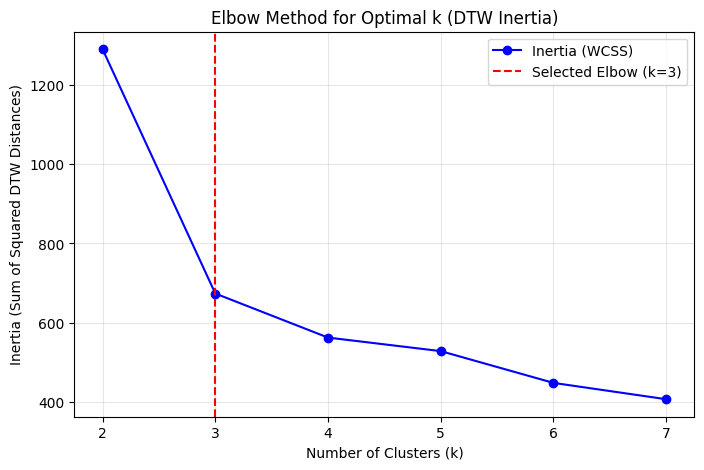

Saving cluster assignments to ../out/out_db.sqlite -> table 'dtw_mvp2_cluster_labels'...
Database save complete.

Plotting DTW Barycenters...
Saved DTW Barycenters plot to ../out/dtw_mvp2_barycenters.png


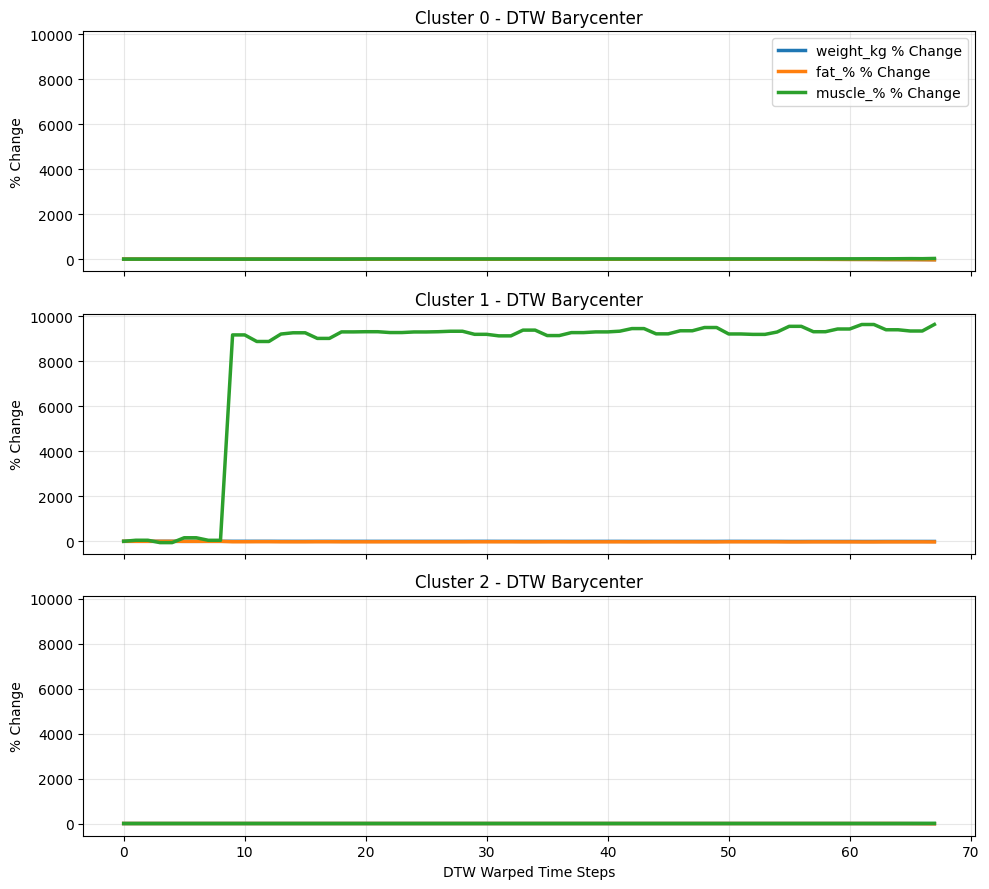


Plotting real-time LOWESS trajectories...
Saved LOWESS plot to ../out/dtw_mvp2_lowess.png


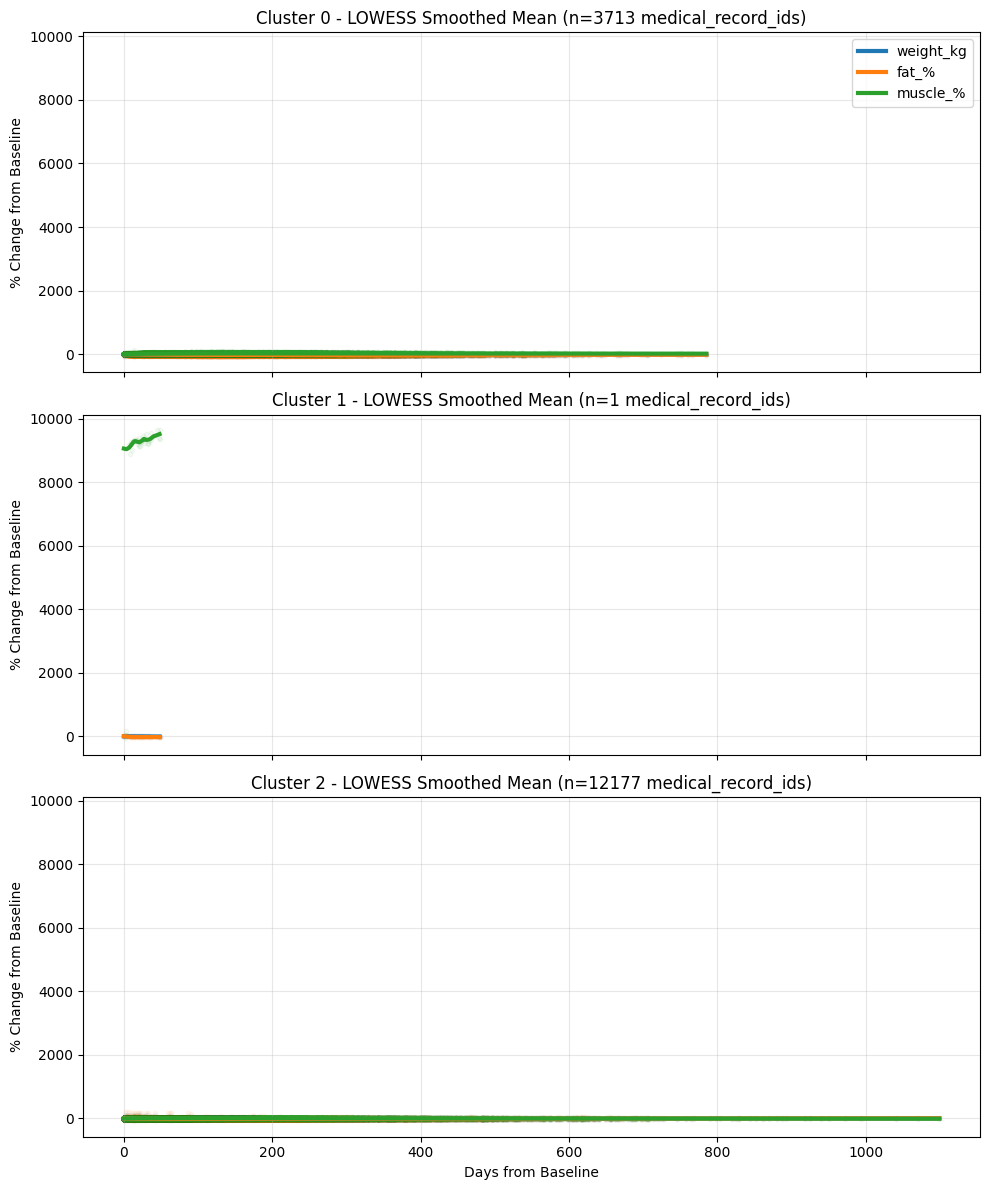

In [1]:
# -------------------------------------------------------------------------
# Dynamic Time Warping with K-means on longitudinal trajectories - MVP2
# -------------------------------------------------------------------------
import os
import sys

# Import our modular pipeline functions
from mdtw_mvp2 import (
    load_and_filter_measurements,
    calculate_days_from_baseline,
    calculate_percentage_from_baseline,
    prepare_tslearn_dataset,
    run_dtw_clustering_search,
    save_clusters_to_db,
    plot_dtw_barycenters,
    plot_lowess_trajectories
)

# -------------------------------------------------------------------------
# 1. CONFIGURATION
# -------------------------------------------------------------------------
# Define paths
DB_PATH = "../dbs/pnk_db2_filtered.sqlite"
OUT_DB_PATH = "../out/out_db.sqlite"
OUT_TABLE = "dtw_mvp2_cluster_labels"

# Configuration variables for the analysis:
# id_col: 'medical_record_id' focuses the analysis on individual treatment 
#         episodes rather than the whole patient history ('patient_id'), 
#         preventing long gaps between distinct treatments from distorting DTW.
ID_COL = "medical_record_id"

# target_cols: The variables we want to cluster on to find distinct weight loss responses.
TARGET_COLS = ["weight_kg", "fat_%", "muscle_%"]

# max_weighins: Excludes extreme outliers (e.g., highly adherent patients with >50 visits)
#               for this MVP run, as DTW is computationally heavy (O(N^2)). 
MAX_WEIGHINS = 68

# -------------------------------------------------------------------------
# 2. DATA PREPARATION
# -------------------------------------------------------------------------
# Load data and apply biological/quality constraints (no missing data, >=2 timepoints)
df_raw = load_and_filter_measurements(
    db_path=DB_PATH, 
    id_col=ID_COL, 
    target_cols=TARGET_COLS, 
    max_weighins=MAX_WEIGHINS
)

# Calculate a continuous time axis (days from baseline) for later visualization
df_time = calculate_days_from_baseline(df_raw, id_col=ID_COL)

# Convert raw measurements into percentage change from the first visit 
# (baseline) to standardize the trajectories for shape-based clustering.
df_pct = calculate_percentage_from_baseline(
    df_time, 
    id_col=ID_COL, 
    target_cols=TARGET_COLS
)

# Reshape the longitudinal dataframe into a 3D tensor (entities x time x features)
# This format is required by tslearn. Uneven histories are automatically zero-padded.
ts_dataset, entity_ids = prepare_tslearn_dataset(
    df_pct, 
    id_col=ID_COL, 
    target_cols=TARGET_COLS
)

# -------------------------------------------------------------------------
# 3. MODELING & CLUSTERING (Updated for Inertia / Elbow Method)
# -------------------------------------------------------------------------
# Iterate through k=2 to k=7 to find the optimal number of clusters using DTW-KMeans.
# Evaluation is done via Inertia (WCSS), detecting the elbow point automatically.
best_k, best_model, best_labels = run_dtw_clustering_search(
    ts_dataset=ts_dataset, 
    k_min=2, 
    k_max=7, 
    elbow_plot_path="../out/dtw_mvp2_elbow_curve.png"  # <--- New configurable path
)

# Save the resulting cluster labels back to our output database for downstream analysis
save_clusters_to_db(
    ids=entity_ids, 
    labels=best_labels, 
    db_path=OUT_DB_PATH, 
    table_name=OUT_TABLE,
    id_col=ID_COL
)

# -------------------------------------------------------------------------
# 4. VISUALIZATION
# -------------------------------------------------------------------------
# Plot the mathematical cluster centers (Barycenters) to see the DTW-derived "shape"
print("\nPlotting DTW Barycenters...")
plot_dtw_barycenters(
    model=best_model, 
    target_cols=TARGET_COLS, 
    output_path="../out/dtw_mvp2_barycenters.png"
)

# Plot the raw, real-time trajectories smoothed by LOWESS to ensure the 
# mathematical clusters align with clinically coherent real-life patterns.
print("\nPlotting real-time LOWESS trajectories...")
plot_lowess_trajectories(
    df=df_pct, 
    ids=entity_ids, 
    labels=best_labels, 
    id_col=ID_COL,
    target_cols=TARGET_COLS,
    output_path="../out/dtw_mvp2_lowess.png"
)


#### MVP1, 17Sept26 - Dynamic time warping with K-means on whole patient trajectory weight and BC data

##### details

GOAL
- to identify weight loss and body composition change trajectory clusters

DATAPREP
- whole patient trajectories used (unit of analysis determined by patient_id)
- instant dropouts excluded - dtw needs serial data - but clinically, they constitute the 0th cluster that should be characterized
- patients with missing BC excluded - dtw needs complete data - missing data would need imputation if we want to use all
- ! most adherent patients excluded: patients with over 50 weigh-ins excluded from the first run, because it slows down early iteration - but these patients are valuable, the top 10% of patients have an average of 107 weigh-ins, and the top has 752
- tensor formatting: uneven patient histories are zero-padded with NaNs and pivoted into a 3D tensor

ML ARCHITECTURE
- algorithm: TimeSeriesKMeans with dynamic time warping. DTW aligns sequence shapes elastically, neutralizing irregular gaps between weigh-ins. It natively ignores NaN padding. 
- k selection: k 2-7 evaluated, best selected with a silhouette score only. But, silhouette evaluation is executed on a random subsample of n max = 1000 per cluster, because it would take too much time on the 14-15k samples

VISUALIZATION
- model-derived: DTW barycenters / raw mathematical cluster centers plotted around warped time steps to emphasize the model-derived SHAPE of the weight loss response
- raw, LOWESS-smoothed: per cluster, raw change trajectories are plotted, to see if clusters actually look coherent in real life, or only their warped trajectory shape

##### code

c:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\p4_dir\.venv\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Loading data from C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/dbs/pnk_db2_filtered.sqlite...
Initial data: 396210 rows, 14515 patients.
After dropping missing values: 360306 rows.
After enforcing >=2 timepoints: 359638 rows, 13770 patients remaining.
After capping at 50 timepoints: 202865 rows, 12150 patients.
Calculating days from baseline for time axis...
Calculating percentage change from baseline...
Reshaping data for tslearn...
Dataset reshaped successfully. Shape: (12150, 50, 3)
Starting DTW KMeans search for k in range 2-7...

--- Fitting k=2 ---
Computing silhouette score on subset of 2000 trajectories...
k=2 | Silhouette Score: 0.4892

--- Fitting k=3 ---
Computing silhouette score on subset of 3000 trajectories...
k=3 | Silhouette Score: 0.3749

--- Fitting k=4 ---
Computing silhouette score on subset of 3358 trajectories...
k=4 | Silhouette Score: 0.3123

--- Fitting k=5 ---
Computing silhouette score on subset of 3753 trajectories...
k=5 | Silhouette Sc

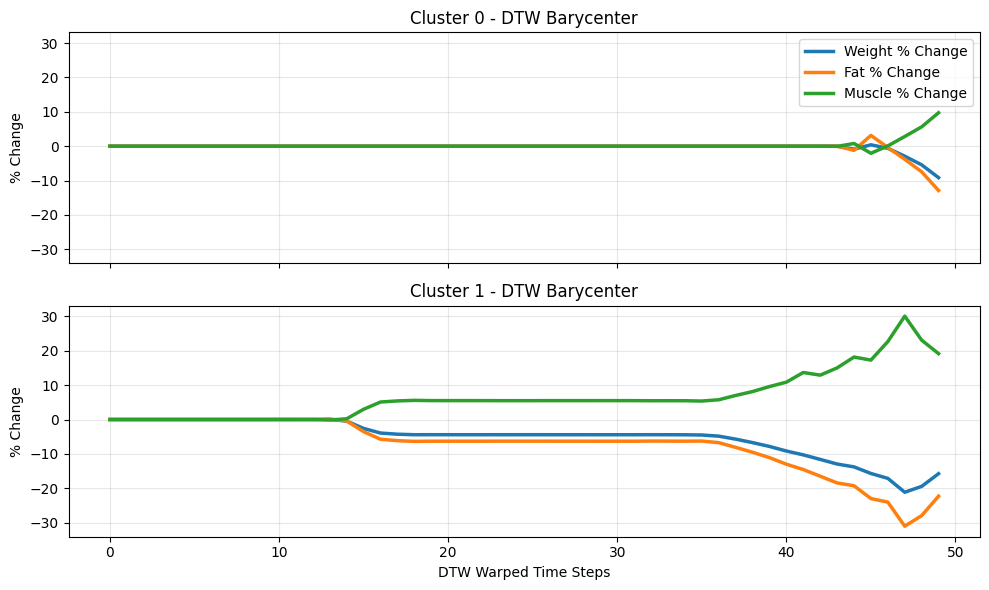

Saved LOWESS plot to C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/out/lowess_trajectories.png


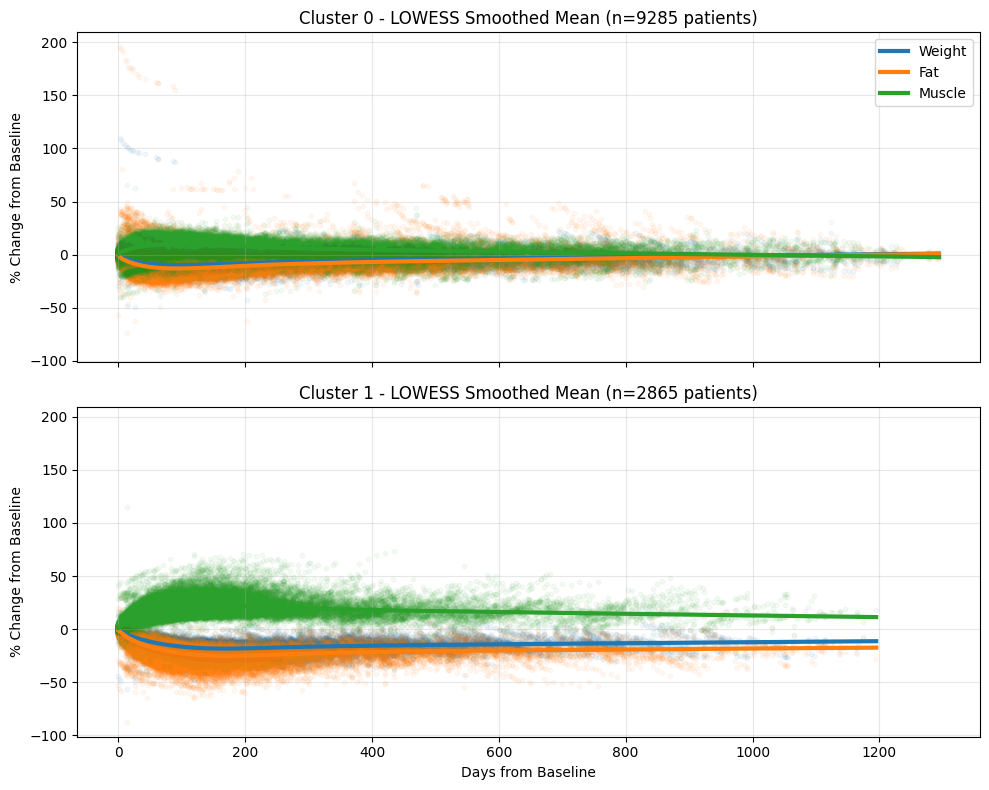

In [1]:
import sys
# Ensure the scripts directory is in path so we can import the module
sys.path.append('scripts')
import mdtw_mvp1

# ==========================================
# 1. CONFIGURATION
# ==========================================
SOURCE_DB_PATH = "C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/dbs/pnk_db2_filtered.sqlite"
OUTPUT_DB_PATH = "C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/out/out_db.sqlite"
OUTPUT_TABLE_NAME = "dtw_mvp1_cluster_labels"

BARYCENTER_PLOT_PATH = "C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/out/dtw_barycenters.png"
LOWESS_PLOT_PATH = "C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/out/lowess_trajectories.png"

# ==========================================
# 2. DATA PREPARATION
# ==========================================
# Load and filter missing or insufficient trajectories
df_clean = mdtw_mvp1.load_and_filter_measurements(SOURCE_DB_PATH)

# Calculate elapsed time (days) for Lowess X-axis
df_clean = mdtw_mvp1.calculate_days_from_baseline(df_clean)

# Calculate Percentage Change from Baseline (Y-axis)
df_norm = mdtw_mvp1.calculate_percentage_from_baseline(df_clean)

# Pivot to tslearn 3D NumPy array
ts_dataset, patient_ids = mdtw_mvp1.prepare_tslearn_dataset(df_norm)

# ==========================================
# 3. DTW CLUSTERING (k=2 to 7)
# ==========================================
# Run silhouette search. n_max_silhouette=1000 bounds the computational 
# cost of DTW distances during evaluation.
best_k, best_model, best_labels = mdtw_mvp1.run_dtw_clustering_search(
    ts_dataset, 
    k_min=2, 
    k_max=7, 
    n_max_silhouette=1000
)

# Save the winning assignments to a new table/database
mdtw_mvp1.save_clusters_to_db(patient_ids, best_labels, OUTPUT_DB_PATH, OUTPUT_TABLE_NAME)

# ==========================================
# 4. VISUALIZATIONS
# ==========================================
# Plot 1: DTW Mathematical Barycenters
mdtw_mvp1.plot_dtw_barycenters(best_model, output_path=BARYCENTER_PLOT_PATH)

# Plot 2: LOWESS Smoothed Mean Trajectories
mdtw_mvp1.plot_lowess_trajectories(df_norm, patient_ids, best_labels, output_path=LOWESS_PLOT_PATH)
